In [67]:
import math
import matplotlib.pyplot as plt

In [68]:
def plot_function(f, a = -10, b = 10, n = 4096):
  xs = [a + (i * ((b - a) / n)) for i in range(n + 1)]
  ys = [f(x) for x in xs]
  plt.plot(xs, ys)
  plt.show()

In [69]:
def simpson_integrate(f, a = -1024, b = 1024, n = 8192):
  result = 0
  for i in range(0, n - 1, 2):
    x0 = a + ((b - a) * (i / n))
    x1 = a + ((b - a) * ((i + 1) / n))
    x2 = a + ((b - a) * ((i + 2) / n))
    h = (b - a) / n
    cur_area = (h / 3) * ((f(x0) + (4 * f(x1)) + f(x2)))
    result += cur_area
  return result

In [70]:
def make_gaussian(mean, stdev):
  def gaussian(x):
    return (1 / (stdev * math.sqrt(math.pi * 2))) * math.exp(-0.5* (((x - mean) / stdev) ** 2))
  
  return gaussian

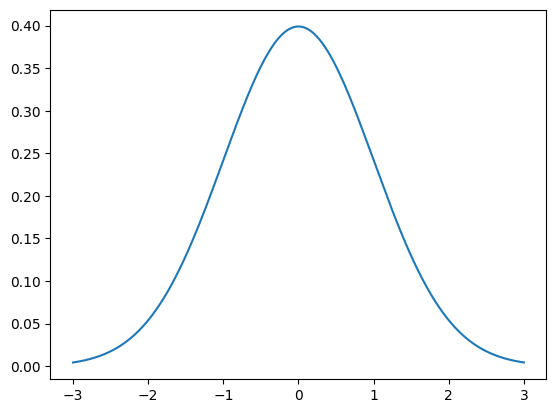

1.0

In [71]:
std_normal_dist = make_gaussian(mean = 0.0, stdev = 1.0)
plot_function(std_normal_dist, -3, 3)
simpson_integrate(std_normal_dist)

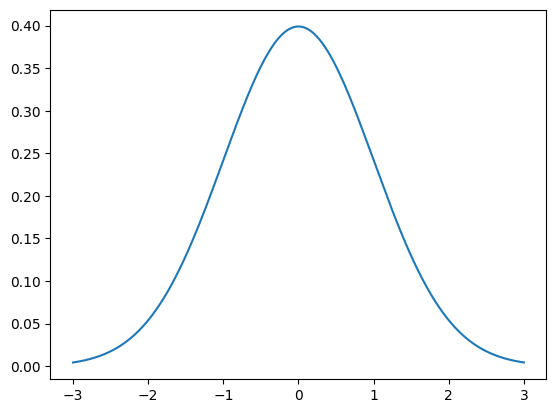

In [72]:
location = make_gaussian(0, 1)
plot_function(location, -3, 3)

In [73]:
def sensor_likelihood(y, x):
  f = make_gaussian(x, 1.0)
  return f(y)

In [74]:
def true_loc_likelihood(x, y):
  def numerator(_x):
    return sensor_likelihood(y, _x) * location(_x)
  evidence = simpson_integrate(numerator)
  return numerator(x) / evidence

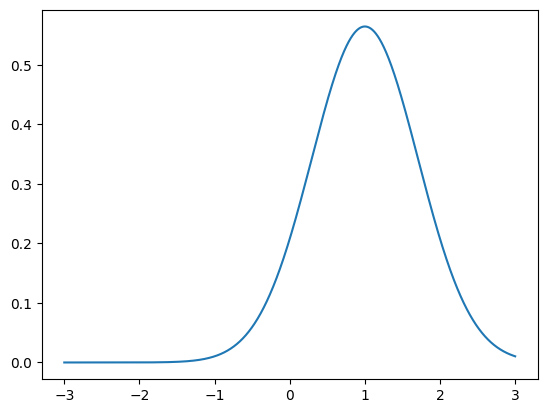

In [75]:
def posterior(x):
  return true_loc_likelihood(x, 2.0)

plot_function(posterior, -3, 3)